In [17]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

np.random.seed(42)  # For reproducibility

for i in range(1000):  # Adjust loop count if desired
    # Generate data for column A (normal distribution)
    column_A = np.random.normal(loc=50, scale=10, size=500)
    
    # Randomize loc and scale for data generation
    loc_low = np.random.uniform(20, 40)  # Random loc for low data
    scale_low = np.random.uniform(2, 8)  # Random scale for low data
    loc_high = np.random.uniform(60, 80)  # Random loc for high data
    scale_high = np.random.uniform(2, 8)  # Random scale for high data
    
    # Generate data for column B (bimodal distribution)
    data_low = np.random.normal(loc=loc_low, scale=scale_low, size=250)
    data_high = np.random.normal(loc=loc_high, scale=scale_high, size=250)
    column_B = np.concatenate([data_low, data_high])
    
    # Shuffle to make it truly bimodal
    np.random.shuffle(column_B)
    
    # Create dataframe
    df = pd.DataFrame({'A': column_A, 'B': column_B})
    
    # Apply statistical tests
    t_stat, p_value_A = ttest_ind(df['A'], df['B'])
    test_stat, p_value_B = mannwhitneyu(df['A'], df['B'])
    
    # Print and break the loop if conditions are met
    if p_value_A > 0.05 and p_value_B < 0.05:
        print("Simulation run:", i+1)
        print(f"t-test results: p-value = {p_value_A}")
        print(f"Mann-Whitney U results: p-value = {p_value_B}")
        print(f"Random loc/scale for low data: loc={loc_low}, scale={scale_low}")
        print(f"Random loc/scale for high data: loc={loc_high}, scale={scale_high}")
        break

Simulation run: 23
t-test results: p-value = 0.1842606276048518
Mann-Whitney U results: p-value = 0.012999767378192615
Random loc/scale for low data: loc=39.36013312413221, scale=7.508111243418072
Random loc/scale for high data: loc=62.531590798252466, scale=2.6761470010624926


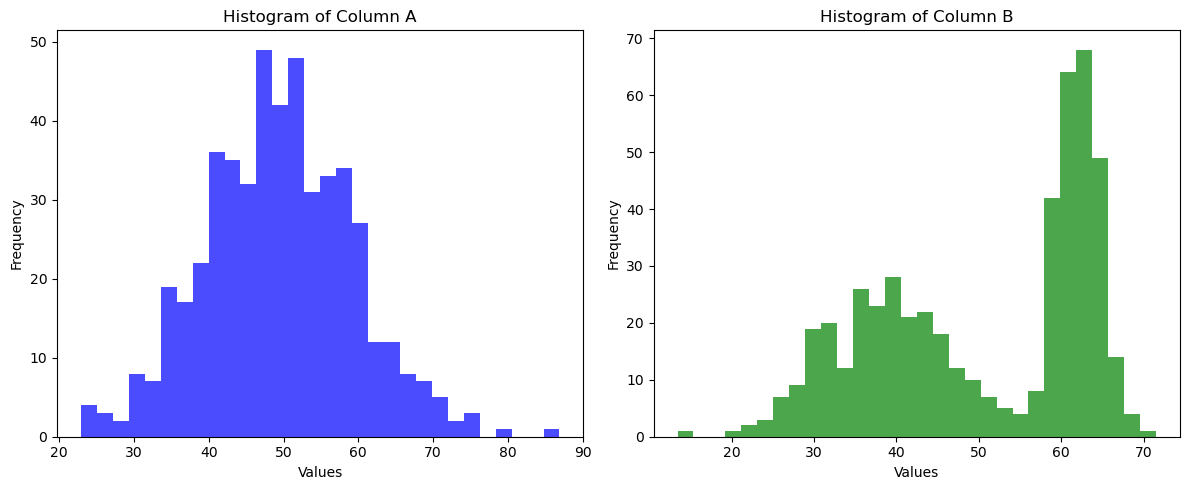

In [18]:

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(column_A, bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Column A')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(column_B, bins=30, color='green', alpha=0.7)
plt.title('Histogram of Column B')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [19]:
p_value_A

0.1842606276048518

In [20]:
p_value_B

0.012999767378192615

In [21]:
df.to_csv("input_data/data.csv")